In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from ucimlrepo import fetch_ucirepo
mushroom = fetch_ucirepo(id=73)
X = mushroom.data.features 
y = mushroom.data.targets
print(X)
print(y)

     cap-shape cap-surface cap-color bruises odor gill-attachment  \
0            x           s         n       t    p               f   
1            x           s         y       t    a               f   
2            b           s         w       t    l               f   
3            x           y         w       t    p               f   
4            x           s         g       f    n               f   
...        ...         ...       ...     ...  ...             ...   
8119         k           s         n       f    n               a   
8120         x           s         n       f    n               a   
8121         f           s         n       f    n               a   
8122         k           y         n       f    y               f   
8123         x           s         n       f    n               a   

     gill-spacing gill-size gill-color stalk-shape  ...  \
0               c         n          k           e  ...   
1               c         b          k           e  .

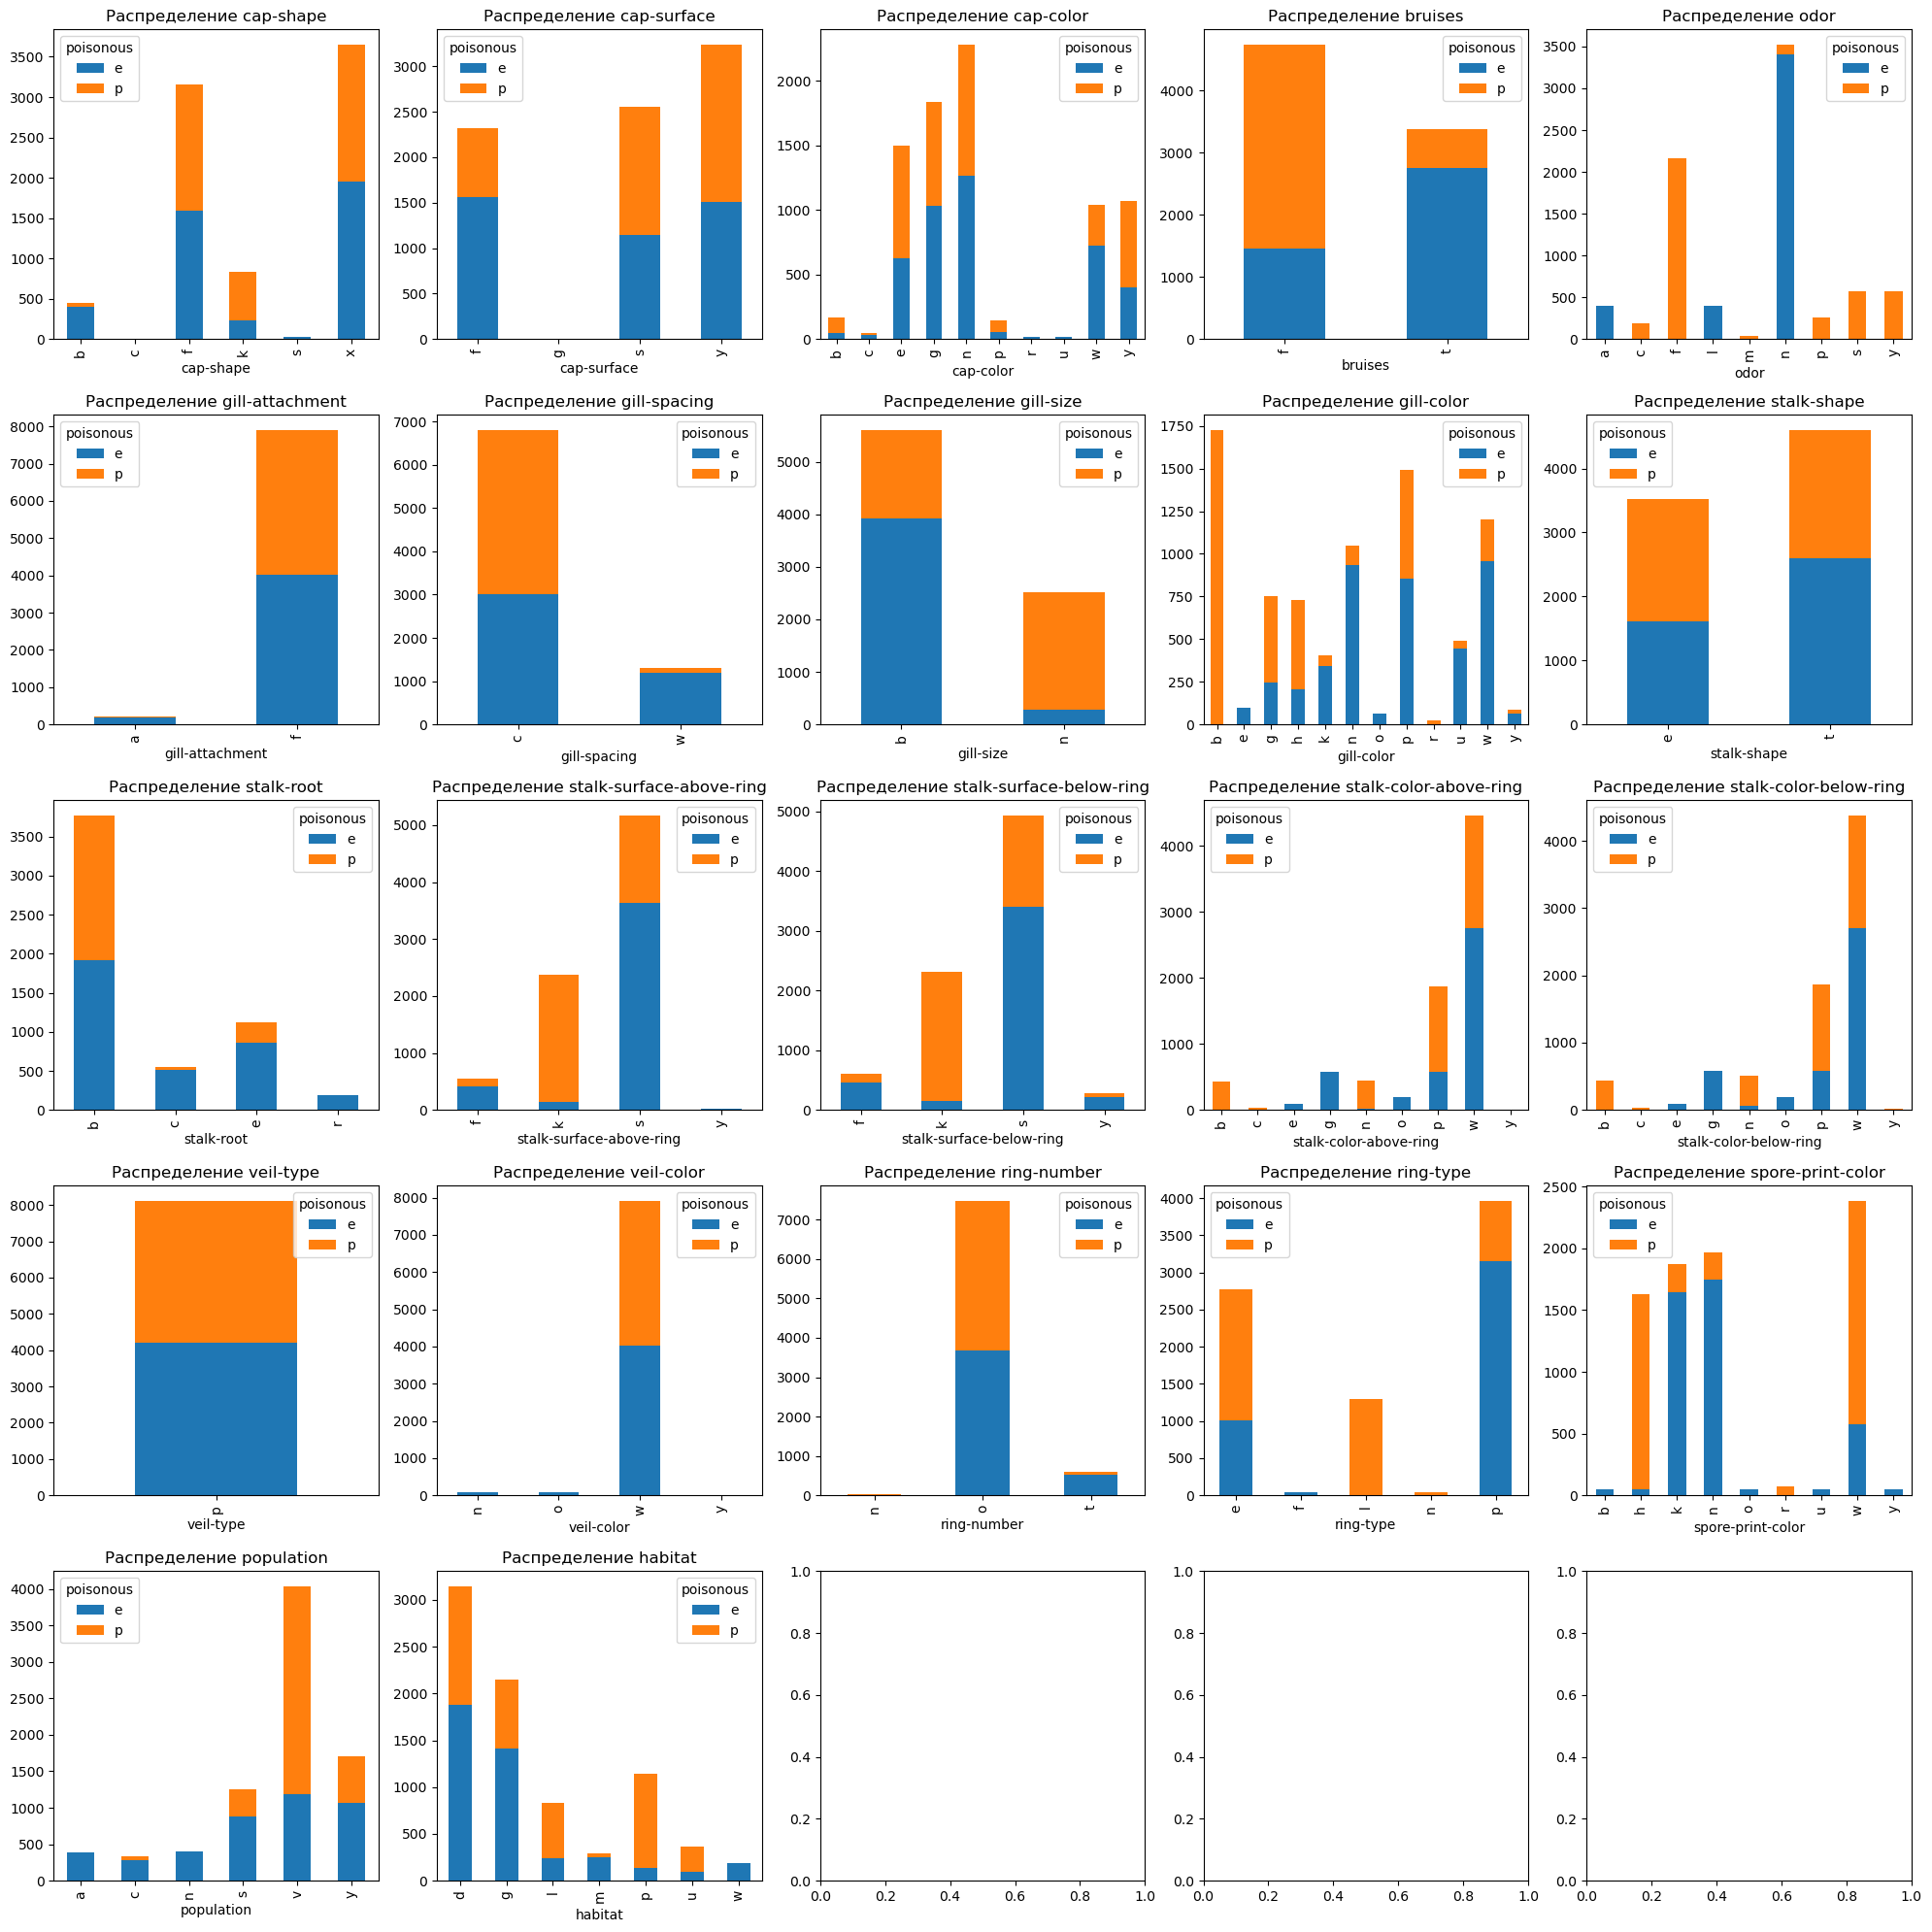

In [ ]:
#Вычисление распределения значений категориальных признаков по классам + визуализация
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.ravel()

for i, col in enumerate(X.columns):
    distribution = X.groupby([col, y["poisonous"]]).size().unstack(fill_value=0)
    distribution.plot(kind="bar", stacked=True, ax=axes[i])
    axes[i].set_title(f'Распределение {col}')

plt.tight_layout()
plt.show()


In [ ]:
#решающая функция на основе частот
def single_feature_accuracy(df, target, feature):
    #y = arg max P(Y=y|X_j=x)
    mapping = df.groupby(feature)[target].agg(lambda x: x.value_counts().idxmax())
    preds = df[feature].map(mapping)
    accuracy = (preds == df[target]).mean()
    return accuracy

feature_accuracies = []

for col in X.columns:
    acc = single_feature_accuracy(pd.concat([X, y], axis=1), 'poisonous', col)
    feature_accuracies.append((col, acc))

sorted_accuracies = sorted(feature_accuracies, key=lambda x: x[1], reverse=True)

#наиболее информативная переменная (с минимальным числом ошибок).
best_feature, best_accuracy = sorted_accuracies[0]
print(f"\nНаиболее информативный признак: {best_feature} с точностью {best_accuracy:.4f}")


Наиболее информативный признак: odor с точностью 0.9852


In [ ]:
#«наивный» байесовский классификатор
#основан на теореме Байеса P(A|B) = P(B|A)*P(A)/P(B)
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix

le = LabelEncoder()
y_clean = le.fit_transform(y["poisonous"])

for column in X.columns:
    X.loc[:, column] = le.fit_transform(X[column])

model = CategoricalNB()
model.fit(X, y_clean)
y_pred = model.predict(X)
res = confusion_matrix(y_clean, y_pred)
print(res) 

[[4188   20]
 [ 332 3584]]


In [ ]:
# acc = TP + TN / TP + FP + FN + TN
total = res[0][0] + res[0][1] + res[1][0] + res[1][1]
accuracy = (res[0][0] + res[1][1]) / total 
print(f"Общая точность: {accuracy:.3f} ({accuracy*100:.1f}%)") 

Общая точность: 0.957 (95.7%)


In [ ]:
class NaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
    
    def fit(self, X, y):
        y = pd.Series(y)
        self.classes = y.unique()
        self.class_counts = y.value_counts()
        N = len(y)
        
        # Априорные вероятности
        # P(Y=c)=count(c)/N
        self.class_priors = self.class_counts / N
        
        self.feature_probs = {}
        for cls in self.classes:
            class_data = X[y == cls]
            self.feature_probs[cls] = {}
            
            for col in X.columns:
                value_counts = class_data[col].value_counts()
                total_class_samples = len(class_data)
                unique_values = X[col].unique()
                
                self.feature_probs[cls][col] = {
                    val: (value_counts.get(val, 0) + self.alpha) / 
                         (total_class_samples + self.alpha * len(unique_values))
                    for val in unique_values
                }
                # Апостерионая вероятность
                # P(X_j=v|Y=c) = (count(X_j=v,Y=c) + alpha) / (N_c + alpha * |V_j|)
                # (count(X_j=v,Y=c) - сколько раз значение v встречается в классе c
                # N_c -  общее количество наблюдений класса c
                # |V_j| - количество уникальных значений признака j
    
    def predict(self, X):
        predictions = []
        
        for _, row in X.iterrows():
            class_scores = {}
            
            for cls in self.classes:
                score = self.class_priors[cls]  # P(Y=c)
                
                for col in X.columns:
                    val = row[col]
                    score *= self.feature_probs[cls][col][val] # P(X_j=v|Y=c)
                class_scores[cls] = score

            total_score = sum(class_scores.values())
            normalized_scores = {cls: score/total_score for cls, score in class_scores.items()}
            # P(A_j|B) = P(B|A_j)*P(A_j)/sum(P(B|A_i)*P(A_i)) = score/total_score
            predicted_class = max(normalized_scores, key=normalized_scores.get)
            predictions.append(predicted_class)
        
        return pd.Series(predictions)

In [ ]:
from sklearn.metrics import confusion_matrix

custom_nb = NaiveBayes()

custom_nb.fit(X, y_clean)
y_pred = custom_nb.predict(X)

confusion_matrix(y_clean, y_pred)

array([[4188,   20],
       [ 332, 3584]])

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class BayesianLogOddsEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.eps = 1e-15
    
    def fit(self, X, y):
        y = pd.Series(y)
        self.classes = y.unique()
        self.class_counts = y.value_counts()
        N = len(y)
        
        # Априорные вероятности
        # P(Y=c)=count(c)/N
        self.class_priors = self.class_counts / N
        
        self.feature_probs = {}
        for cls in self.classes:
            class_data = X[y == cls]
            self.feature_probs[cls] = {}
            
            for col in X.columns:
                value_counts = class_data[col].value_counts()
                total_class_samples = len(class_data)
                unique_values = X[col].unique()

                self.feature_probs[cls][col] = {
                    val: (value_counts.get(val, 0) + self.alpha) / 
                         (total_class_samples + self.alpha * len(unique_values))
                    for val in unique_values
                }
                # Апостерионая вероятность
                # P(X_j=v|Y=c) = (count(X_j=v,Y=c) + alpha) / (N_c + alpha * |V_j|)
                # (count(X_j=v,Y=c) - сколько раз значение v встречается в классе c
                # N_c -  общее количество наблюдений класса c
                # |V_j| - количество уникальных значений признака j
        
        return self
    
    def transform(self, X):
        X_transformed = pd.DataFrame(index=X.index)
        
        for col in X.columns:
            for c in self.classes:
                probs_dict = self.feature_probs[c][col]  # P(X_j=v|Y=c)
                
                # обратное логистическое преобразование
                # log(p / (1-p)) - переводим вероятности на бесконечное просранство
                logits_dict = {}
                for val, prob in probs_dict.items():
                    p = np.clip(prob, self.eps, 1 - self.eps)
                    log_odds = np.log(p / (1 - p))
                    logits_dict[val] = log_odds
                
                feature_name = f"{col}_class_{c}"
                X_transformed[feature_name] = X[col].map(logits_dict)
                
                X_transformed[feature_name] = X_transformed[feature_name].fillna(0)
        return X_transformed

In [ ]:
be = BayesianLogOddsEncoder()
be.fit_transform(X, y_clean)

,cap-shape_class_1,cap-shape_class_0,cap-surface_class_1,cap-surface_class_0,cap-color_class_1,cap-color_class_0,bruises_class_1,bruises_class_0,odor_class_1,odor_class_0,...,ring-number_class_1,ring-number_class_0,ring-type_class_1,ring-type_class_0,spore-print-color_class_1,spore-print-color_class_0,population_class_1,population_class_0,habitat_class_1,habitat_class_0
0,-0.258441,-0.150258,-0.573372,-0.985295,-1.045651,-0.847749,-1.661803,0.636312,-2.658326,-8.346642,...,3.544642,1.938063,-1.334808,1.090085,-2.799988,-0.442958,-2.264751,-1.330570,-2.593011,-3.748412
1,-0.258441,-0.150258,-0.573372,-0.985295,-1.575588,-2.253259,-1.661803,0.636312,-8.274867,-2.252997,...,3.544642,1.938063,-1.334808,1.090085,-2.799988,-0.348273,-8.274102,-2.252210,-1.457265,-0.688880
2,-4.369964,-2.241235,-0.573372,-0.985295,-2.418636,-1.579022,-1.661803,0.636312,-8.274867,-2.252997,...,3.544642,1.938063,-1.334808,1.090085,-2.799988,-0.348273,-8.274102,-2.252210,-4.654218,-2.734418
3,-0.258441,-0.150258,-0.224406,-0.587048,-2.418636,-1.579022,-1.661803,0.636312,-2.658326,-8.346642,...,3.544642,1.938063,-1.334808,1.090085,-2.799988,-0.442958,-2.264751,-1.330570,-2.593011,-3.748412
4,-0.258441,-0.150258,-0.573372,-0.985295,-1.348827,-1.125985,1.661803,-0.636312,-3.448018,1.439612,...,3.544642,1.938063,-0.195983,-1.155440,-2.799988,-0.348273,-8.274102,-2.297116,-1.457265,-0.688880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,-1.709426,-2.856571,-0.573372,-0.985295,-1.045651,-0.847749,1.661803,-0.636312,-3.448018,1.439612,...,3.544642,1.938063,-1.334808,1.090085,-8.274867,-4.443371,-4.290459,-2.608695,-1.725533,-2.802731
8120,-0.258441,-0.150258,-0.573372,-0.985295,-1.045651,-0.847749,1.661803,-0.636312,-3.448018,1.439612,...,3.544642,1.938063,-1.334808,1.090085,-8.274867,-4.443371,0.976510,-0.929117,-1.725533,-2.802731
8121,-0.418017,-0.493902,-0.573372,-0.985295,-1.045651,-0.847749,1.661803,-0.636312,-3.448018,1.439612,...,3.544642,1.938063,-1.334808,1.090085,-8.274867,-4.443371,-4.290459,-2.608695,-1.725533,-2.802731
8122,-1.709426,-2.856571,-0.224406,-0.587048,-1.045651,-0.847749,1.661803,-0.636312,-1.758276,-8.346642,...,3.544642,1.938063,-0.195983,-1.155440,-0.152652,-1.841897,0.976510,-0.929117,-1.725533,-2.802731


In [ ]:
from sklearn.linear_model import LogisticRegression

be = BayesianLogOddsEncoder()
X_transformed = be.fit_transform(X, y_clean)

lr = LogisticRegression(max_iter=100000)
lr.fit(X_transformed, y_clean)
y_pred = lr.predict(X_transformed)

res = confusion_matrix(y_clean, y_pred)
print(res)

[[4208    0]
 [   0 3916]]


In [ ]:
coefficients = lr.coef_[0]
feature_names = X_transformed.columns if hasattr(X_transformed, 'columns') else [f"Feature_{i}" for i in range(X_transformed.shape[1])]
feature_importance = sorted(zip(feature_names, coefficients), 
                           key=lambda x: abs(x[1]), 
                           reverse=True)
top_n = min(10, len(feature_importance))
feature_importance[:top_n]

[('spore-print-color_class_0', np.float64(-2.1176215410363777)),
 ('odor_class_1', np.float64(1.6210132321278226)),
 ('odor_class_0', np.float64(-1.5761767981125188)),
 ('gill-size_class_0', np.float64(-1.3811908501073236)),
 ('bruises_class_1', np.float64(-1.2027207912519646)),
 ('spore-print-color_class_1', np.float64(0.9744837892652681)),
 ('stalk-surface-above-ring_class_1', np.float64(0.9141943651860233)),
 ('ring-type_class_1', np.float64(0.8763609547992239)),
 ('ring-type_class_0', np.float64(0.716414072111292)),
 ('stalk-surface-above-ring_class_0', np.float64(-0.6531159976246522))]

In [ ]:
# acc = TP + TN / TP + FP + FN + TN
total = res[0][0] + res[0][1] + res[1][0] + res[1][1]
accuracy = (res[0][0] + res[1][1]) / total 
print(f"Общая точность: {accuracy:.3f} ({accuracy*100:.1f}%)") 

Общая точность: 1.000 (100.0%)
